In [1]:
from PIL import Image
from matplotlib import pyplot as plt
import numpy as np
from pathlib import Path

In [17]:
path = "test_image/Lenna_(test_image).png"

img = Image.open(path).convert("RGB")


In [18]:
class JPEGCodec:
    def __init__(self, block_size: int = 8):
        self.N = block_size
        self.C = self._dct_matrix(block_size)

    def _dct_matrix(self, N: int) -> np.ndarray:
        C = np.zeros((N, N), dtype=np.float64)
        for i in range(N):
            for j in range(N):
                alpha = np.sqrt(1 / N) if i == 0 else np.sqrt(2 / N)
                C[i, j] = alpha * np.cos(((2 * j + 1) * i * np.pi) / (2 * N))
        return C
    
    def _split_blocks(self, channel):
        H, W = channel.shape
        assert H % self.N == 0 and W % self.N == 0, "Image dimensions must be divisible by block size"
        return channel.reshape(
            H // self.N, self.N,
            W // self.N, self.N
        ).transpose(0, 2, 1, 3)

    def _merge_blocks(self, blocks):
        nb_h, nb_w, bh, bw = blocks.shape
        return blocks.transpose(0, 2, 1, 3).reshape(nb_h * bh, nb_w * bw)
    
    def _dct2(self, block):
        return self.C @ block @ self.C.T
    
    def _idct2(self, block):
        return self.C.T @ block @ self.C
    
    def transform_blocks(self, blocks):
        out = np.empty_like(blocks, dtype=np.float64)
        for i in range(blocks.shape[0]):
            for j in range(blocks.shape[1]):
                out[i, j] = self._dct2(blocks[i, j])
        return out
    
    def inverse_transform_blocks(self, blocks):
        out = np.empty_like(blocks, dtype=np.float64)
        for i in range(blocks.shape[0]):
            for j in range(blocks.shape[1]):
                out[i, j] = self._idct2(blocks[i, j])
        return out
    
    
    def transform(self, image: Image.Image) -> dict:
        image = image.convert("YCbCr")
        arr = np.asarray(image, dtype=np.uint8).astype(np.float64) - 128.0
        channels = []

        for c in range(3):
            blocks = self._split_blocks(arr[:, :, c])
            dct_blocks = self.transform_blocks(blocks)
            channels.append(dct_blocks)

        return {
            "ch1": channels[0],
            "ch2": channels[1],
            "ch3": channels[2]
        }

    def inverse_transform(self, encoded: dict) -> Image.Image:
        rec_channels = []

        for key in ["ch1", "ch2", "ch3"]:
            blocks = self.inverse_transform_blocks(encoded[key])
            rec_channels.append(self._merge_blocks(blocks))
        
        rec = np.stack(rec_channels, axis=-1)
        return Image.fromarray(np.clip(rec + 128.0, 0, 255).astype(np.uint8), mode="YCbCr").convert("RGB")
    
    def encode(self, image: Image.Image) -> dict:
        output = self.transform(image)
        return output
    
    def decode(self, encoded: dict) -> Image.Image:
        output = self.inverse_transform(encoded)
        return output

In [19]:
codec = JPEGCodec(block_size=8)

transformed = codec.transform(img)
reconstructed = codec.inverse_transform(transformed)

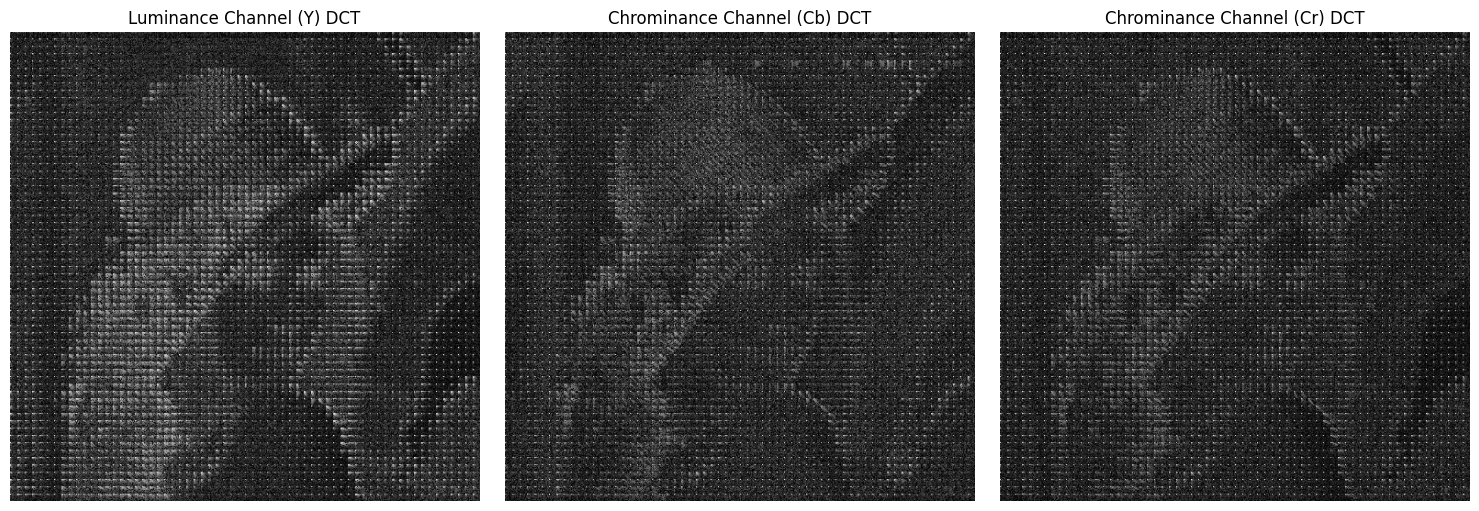

In [23]:
def show_dct_channel(transformed):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for ax, key, title in zip(
        axes,
        ["ch1", "ch2", "ch3"],
        ["Luminance Channel (Y) DCT", "Chrominance Channel (Cb) DCT", "Chrominance Channel (Cr) DCT"]
    ):
        dct_img = codec._merge_blocks(transformed[key])
        vis = np.log1p(np.abs(dct_img))

        ax.imshow(vis, cmap="gray")
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_dct_channel(transformed)


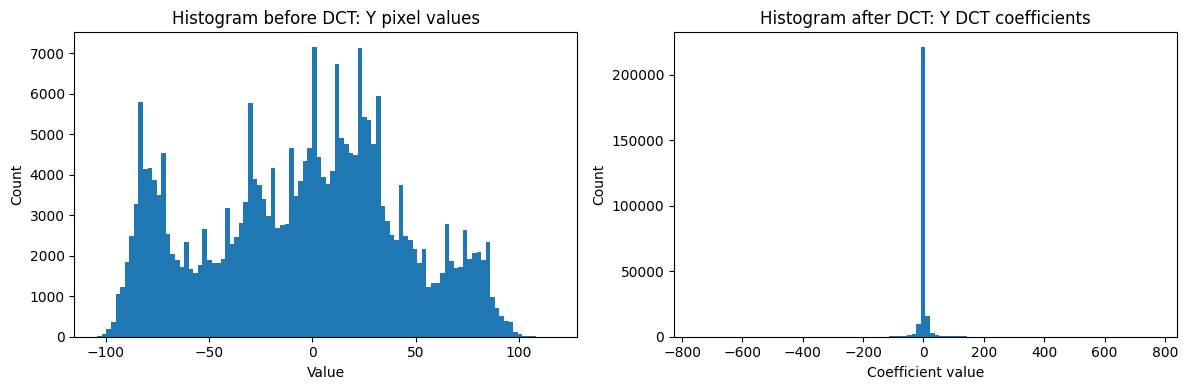

In [ ]:
img_ycbcr = img.convert("YCbCr")
arr = np.asarray(img_ycbcr).astype(np.float64) - 128.0
y_channel = arr[:, :, 0]

dct_y = codec._merge_blocks(transformed["ch1"])

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y_channel.ravel(), bins=100)
plt.title("Histogram before DCT: Y pixel values")
plt.xlabel("Value")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.hist(dct_y.ravel(), bins=100)
plt.title("Histogram after DCT: Y DCT coefficients")
plt.xlabel("Coefficient value")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [21]:


error = np.asarray(img).astype(np.int16) - np.asarray(reconstructed).astype(np.int16)
abs_error = np.abs(error)

print("Min error:", error.min())
print("Max error:", error.max())
print("Mean absolute error:", abs_error.mean())
print("Max absolute error:", abs_error.max())

Min error: -1
Max error: 6
Mean absolute error: 1.7215741475423176
Max absolute error: 6


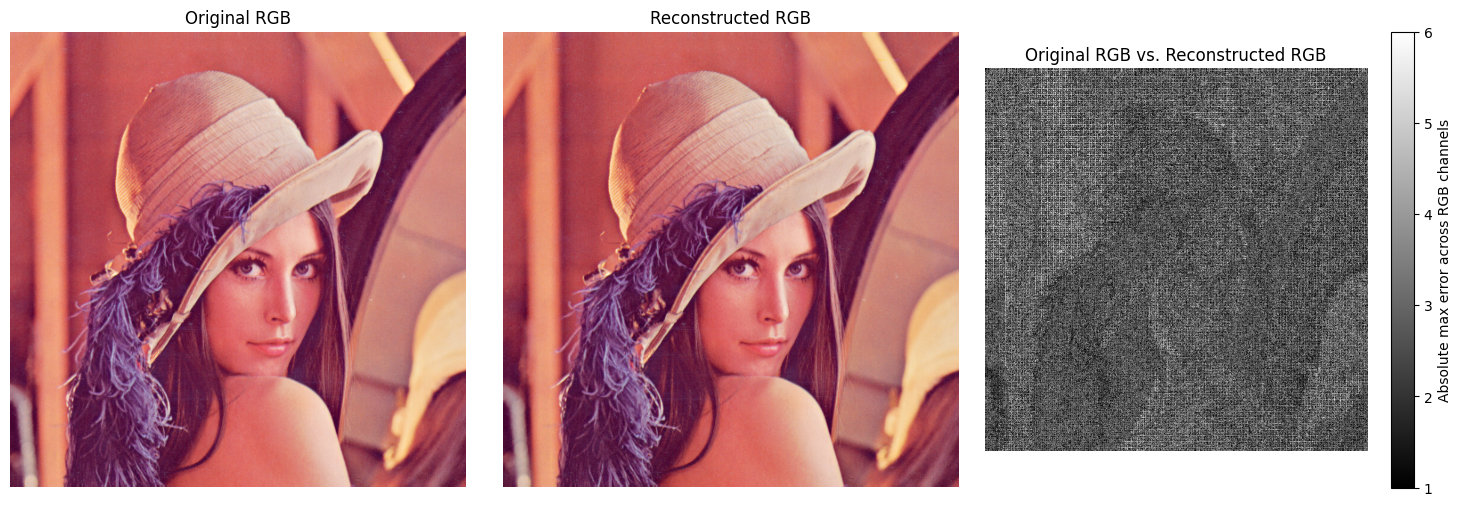

In [28]:
error_vis = abs_error.max(axis=2)  

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(np.asarray(img).astype(np.int16))
plt.title("Original RGB")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(np.asarray(reconstructed).astype(np.int16))
plt.title("Reconstructed RGB")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(error_vis, cmap="gray")
plt.title("Original RGB vs. Reconstructed RGB")
plt.axis("off")
plt.colorbar(label="Absolute max error across RGB channels")

plt.tight_layout()
plt.show()